# Data Analytics - Part 3
#### Serverless Data Engineering Python Pipeline with AWS S3 and Lambda
A fully automated, serverless AWS pipeline for ingesting, processing, and analyzing public datasets. The workflow fully dynamic and flexible by avoiding hardcoding filenames and analyics information. This uses AWS S3 Storage for raw and processed data and AWS Lambda Automates data ingestion & sync

---
#### Workflow
- Ingested labor productivity data (BLS) and population api data into AWS S3.
- Loaded both datasets into Pandas for cleaning and transformation
- This will analyze the following:
  - Mean & standard deviation of US population (2013–2018)
  - Peak year per labor series
  - Merged selected labor productivity data with population figures by year

---
#### Python packages
- `boto3` — AWS SDK; S3 uploads/reads  
- `requests` — call the public APIs  
- `hashlib` — make file hashes to skip dupes  
- `pandas` — clean/reshape data  
- `json` — parse/serialize JSON  
- `io` — in-memory file buffers  
- `kaggle_secrets` — pull keys in Kaggle notebooks


#### Secret Keys
`AWS_ACCESS_KEY_ID` • `AWS_SECRET_ACCESS_KEY` • `AWS_REGION` • `BUCKET_NAME` • `BLS_API_KEY`

## Connect to AWS S3
This section initializes the connection to AWS S3 using credentials stored securely as Kaggle Secrets.  It sets up a boto3 session and client so you can interact with your S3 bucket programmatically.

In [1]:
import boto3
import pandas as pd
from botocore.exceptions import ClientError
from kaggle_secrets import UserSecretsClient
from io import StringIO
import json

# Load secrets
secrets = UserSecretsClient()

config = {
    "AWS_ACCESS_KEY_ID": secrets.get_secret("AWS_ACCESS_KEY_ID"),
    "AWS_SECRET_ACCESS_KEY": secrets.get_secret("AWS_SECRET_ACCESS_KEY"),
    "AWS_REGION": secrets.get_secret("AWS_REGION"),
    "BUCKET_NAME": secrets.get_secret("BUCKET_NAME").strip()
}

# Check secrets
missing = [key for key, value in config.items() if not value]

if missing:
    raise ValueError(f"Missing required secrets: {missing}")

print("SUCCESS: All required secrets found")

# Create AWS clients
session = boto3.Session(
    aws_access_key_id=config["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=config["AWS_SECRET_ACCESS_KEY"],
    region_name=config["AWS_REGION"]
)

s3 = session.client("s3")
sts = session.client("sts")

# Check AWS credentials
try:
    identity = sts.get_caller_identity()
    print("SUCCESS: AWS credentials work")
    print("Account:", identity["Account"])
except ClientError as e:
    print("ERROR: AWS credentials failed")
    print(e.response["Error"]["Code"])
    raise

# Check S3 bucket access
try:
    s3.head_bucket(Bucket=config["BUCKET_NAME"])
    print("SUCCESS: S3 bucket access works")
except ClientError as e:
    code = e.response["Error"].get("Code", "Unknown")
    status = e.response["ResponseMetadata"].get("HTTPStatusCode", "Unknown")

    print(f"ERROR: S3 bucket access failed - HTTP {status}, Code: {code}")

    if status == 403:
        print("Likely cause: wrong account, IAM permissions, or bucket policy.")
    elif status == 404:
        print("Likely cause: bucket name is wrong or bucket does not exist.")
    elif code == "SignatureDoesNotMatch":
        print("Likely cause: AWS secret key is wrong.")
    elif code == "InvalidAccessKeyId":
        print("Likely cause: AWS access key is wrong or inactive.")

    raise

SUCCESS: All required secrets found
SUCCESS: AWS credentials work
Account: 933832705314
SUCCESS: S3 bucket access works


In [2]:
# Optional S3 validation check
resp = s3.list_objects_v2(Bucket=config["BUCKET_NAME"], MaxKeys=1)

if "Contents" in resp:
    print("Number of buckets:", len(s3.list_buckets()["Buckets"]))
    print("S3 bucket connection successful. Objects found.")
else:
    print("S3 bucket connection successful, but no objects found.")

Number of buckets: 11
S3 bucket connection successful. Objects found.


In [3]:
import os
from io import StringIO

prefix = os.getenv("BLS_PREFIX", "bls/time.series/pr/")
name_prefix = os.getenv("BLS_NAME_PREFIX", "pr.data.")
name_suffix = os.getenv("BLS_NAME_SUFFIX", ".Current")

matches = []
paginator = s3.get_paginator("list_objects_v2")
BUCKET_NAME = config["BUCKET_NAME"]

for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix=prefix):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        filename = key.rsplit("/", 1)[-1]
        if filename.startswith(name_prefix) and filename.endswith(name_suffix):
            matches.append(obj)

if not matches:
    raise FileNotFoundError(f"No BLS file found under s3://{BUCKET_NAME}/{prefix}")

bls_key = max(matches, key=lambda o: o["LastModified"])["Key"]  # newest match
obj = s3.get_object(Bucket=BUCKET_NAME, Key=bls_key)
df_bls = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")), sep="\t")

# Load S3 Data into DataFrames
Load the CSV file (`pr.data.0.Current`) and the JSON file (`datausa_population.json`) from AWS S3 into Pandas DataFrames for processing.

In [4]:
BUCKET_NAME = config["BUCKET_NAME"]
# Load the population.json file:
json_key = "datausa_population.json"
obj = s3.get_object(Bucket=BUCKET_NAME, Key=json_key)
population_data = json.loads(obj['Body'].read().decode('utf-8'))
population_data = population_data['data']

df_us_year_population = pd.DataFrame(population_data)

# Clean white space and column names lower to join data later:
df_us_year_population.columns = df_us_year_population.columns.str.strip().str.lower()
df_us_year_population['population'] = df_us_year_population['population'].astype(int)

print("Population Data Shape: ", df_us_year_population.shape)
df_us_year_population.head(10) # there are only 10 rows

Population Data Shape:  (11, 4)


,nation id,nation,year,population
0,01000US,United States,2013,316128839
1,01000US,United States,2014,318857056
2,01000US,United States,2015,321418821
3,01000US,United States,2016,323127515
4,01000US,United States,2017,325719178
5,01000US,United States,2018,327167439
6,01000US,United States,2019,328239523
7,01000US,United States,2021,331893745
8,01000US,United States,2022,333287562
9,01000US,United States,2023,334914896


# Data Analytics on US Population
Using the dataframe from the population data API, here is the mean and the standard deviation of the annual US population across the years [2013, 2018] inclusive.

In [5]:
year1 = 2013
year2 = 2018

def population_stats_by_year_range(df, start_year, end_year):
    filtered_df = df[df["year"].between(start_year, end_year)].copy()

    population_mean = filtered_df["population"].mean()
    population_std = filtered_df["population"].std()

    print(f"Average US population from {start_year} to {end_year}: {round(population_mean)}")
    print(f"Standard deviation during that period: {round(population_std)}")

    return filtered_df, population_mean, population_std


filtered_df, population_mean, population_std = population_stats_by_year_range(
    df_us_year_population, year1,year2)

Average US population from 2013 to 2018: 322069808
Standard deviation during that period: 4158441


# Data Analytics on BLS API Data
Using the time-series BLS dataframe, find the **best year** for each `series_id` — defined as the year with the **maximum total sum** of the `"value"` across all quarters. Generate a report listing each `series_id`, its best year, and the total summed value for that year. For example, if the table had these values:  
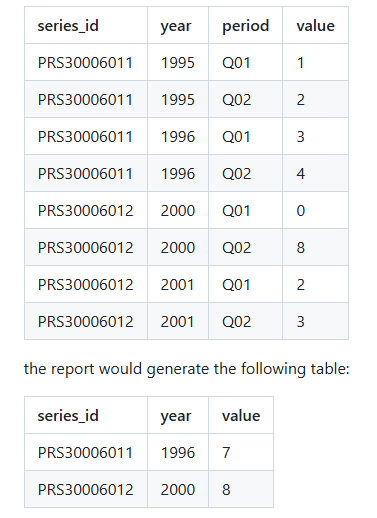

---

### Find Each Series ID's Best Year Based on Total Value

In [6]:
def standardize_headers(df):
    df = df.copy()
    # Standardize column headers by trimming spaces and converting to lowercase
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

df_bls = standardize_headers(df_bls)

In [7]:
df_bls_year = df_bls.groupby(by=['series_id', 'year'])['value'].sum().reset_index()

# Each id find their best year:
idx = df_bls_year.groupby('series_id')['value'].idxmax()  # This method allows you to keep column names
df_bls_best_year = df_bls_year.loc[idx].reset_index(drop=True)

# View Data:
print("Series_id Best Year DataFrame: ", df_bls_best_year.shape)
df_bls_best_year.head()

Series_id Best Year DataFrame:  (282, 3)


,series_id,year,value
0,PRS30006011,2022,20.500
1,PRS30006012,2022,17.100
2,PRS30006013,1998,705.895
3,PRS30006021,2010,17.700
4,PRS30006022,2010,12.400


### Dynamic Report Function

The function below generates a reusable report for any selected BLS `series_id` and `period`. 
It trims whitespace, aligns year data types, joins BLS data with population data, and returns the matching rows with population values when available.

### Trend Visualization

In [8]:
def filter_data(df_bls, df_us_year_population, target_series_id,
                target_period, population_columns, bls_columns):
    
    # Keep only needed columns
    df_us_year_population = df_us_year_population[population_columns].copy()
    df_bls = df_bls[bls_columns].copy()

    # Clean values
    df_bls["series_id"] = df_bls["series_id"].astype(str).str.strip()
    df_bls["period"] = df_bls["period"].astype(str).str.strip()

    # Make sure year columns match
    df_bls["year"] = df_bls["year"].astype(int)
    df_us_year_population["year"] = df_us_year_population["year"].astype(int)

    # Validate that the requested series exists
    if target_series_id not in df_bls["series_id"].unique():
        raise ValueError(f"Series ID not found: {target_series_id}")

    # Merge population and BLS data
    merged_df = pd.merge(df_bls, df_us_year_population, on="year", how="left")

    # Filter using parameters
    df_filtered = merged_df[
        (merged_df["series_id"] == target_series_id) &
        (merged_df["period"] == target_period)
    ].reset_index(drop=True)

    return df_filtered
    

## Generate Report

Using both the BLS and Population dataframes, generate a report showing the `value` for `series_id = PRS30006032` and `period = Q01`, along with the corresponding population for that year if available.

Example output row:

| series_id   | year | period | value | population |
|-------------|------|--------|-------|------------|
| PRS30006032 | 2018 | Q01    | 1.9   | 327167439  |

Perform data cleaning such as trimming whitespace before filtering or joining datasets.

In [9]:
# Analysis parameters
target_series_id = "PRS30006032"
target_period = "Q01"

population_columns = ["year", "population"]
bls_columns = ["series_id", "year", "period", "value"]

# Run filter function
df_filtered = filter_data(
    df_bls,
    df_us_year_population,
    target_series_id,
    target_period,
    population_columns,
    bls_columns
)

# Clean nullable population values for display
df_filtered["population"] = df_filtered["population"].astype("Int64")

df_filtered

,series_id,year,period,value,population
0,PRS30006032,1995,Q01,0.0,<NA>
1,PRS30006032,1996,Q01,-4.2,<NA>
2,PRS30006032,1997,Q01,2.8,<NA>
3,PRS30006032,1998,Q01,0.9,<NA>
4,PRS30006032,1999,Q01,-4.1,<NA>
5,PRS30006032,2000,Q01,0.5,<NA>
6,PRS30006032,2001,Q01,-6.3,<NA>
7,PRS30006032,2002,Q01,-6.6,<NA>
8,PRS30006032,2003,Q01,-5.7,<NA>
9,PRS30006032,2004,Q01,2.0,<NA>


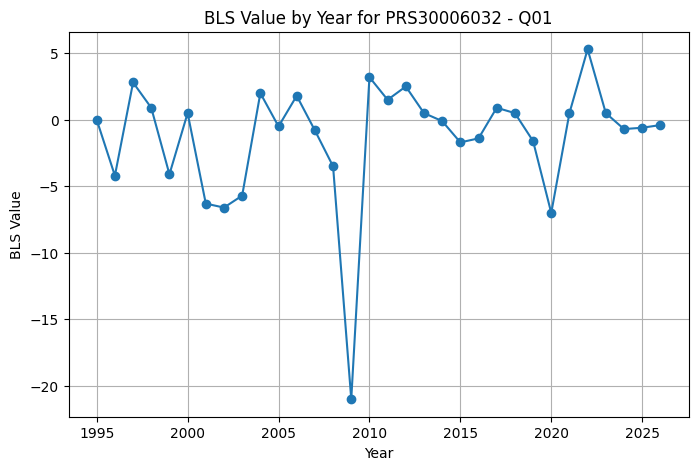

In [10]:
import matplotlib.pyplot as plt

# Make sure values are numeric
df_filtered["value"] = pd.to_numeric(df_filtered["value"], errors="coerce")

# Sort by year for a clean line chart
df_plot = df_filtered.sort_values("year")

plt.figure(figsize=(8, 5))
plt.plot(df_plot["year"], df_plot["value"], marker="o")

plt.title("BLS Value by Year for PRS30006032 - Q01")
plt.xlabel("Year")
plt.ylabel("BLS Value")
plt.grid(True)
plt.show()